<a href="https://colab.research.google.com/github/AkshayMendiratta2006/IncodeVision-ML-Internship/blob/main/Task_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IncodeVision ML Internship - Task 03
**Project:** Spam Email Classifier

**Description:**
This notebook builds a Spam Email Classifier using Natural Language Processing (NLP) techniques. It utilizes Python, pandas, and scikit-learn to preprocess text data, convert the text into numerical features using TF-IDF vectorization, and train a Naive Bayes(MultinomialNB) model. The model's performance is evaluated using accuracy, precision, recall, F1-score, alongside a Seaborn confusion matrix visualizion to analyze false positives and false negatives.

**Dataset:**
The dataset used for this project is the **SMS Spam Collection Dataset**.
* You can download the dataset from Kaggle here: [SMS Spam Collection Dataset on Kaggle](https://www.kaggle.com/datasets/vishakhdapat/sms-spam-detection-dataset)

In [13]:
# Importing libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [14]:
# Loading the dataset
df = pd.read_csv('spam.csv', encoding='latin-1')
df = df[[ 'v1', 'v2']]
df.columns = ['label', 'message']
df['label'] = df['label'].map({'ham': 0, 'spam': 1})
print('--- Class Distribution ---')
print(df['label'].value_counts())
df.head()

--- Class Distribution ---
label
0    4825
1     747
Name: count, dtype: int64


,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [15]:
# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(df['message'], df['label'], test_size=0.2, random_state=42)

In [16]:
# Convert text to numbers using TF-IDF
vectorizer = TfidfVectorizer(stop_words='english')
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [17]:
# Training the Naive-Bayes Model
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

MultinomialNB()

In [18]:
# Making the prediction
y_pred = model.predict(X_test_tfidf)

In [19]:
# Evaluate the model
print('--- Model Evaluation ---')
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print(f'Recall: {recall_score(y_test, y_pred):.4f}')
print(f'F1 Score: {f1_score(y_test, y_pred):.4f}')

--- Model Evaluation ---
Accuracy: 0.9668
Precision: 1.0000
Recall: 0.7533
F1 Score: 0.8593


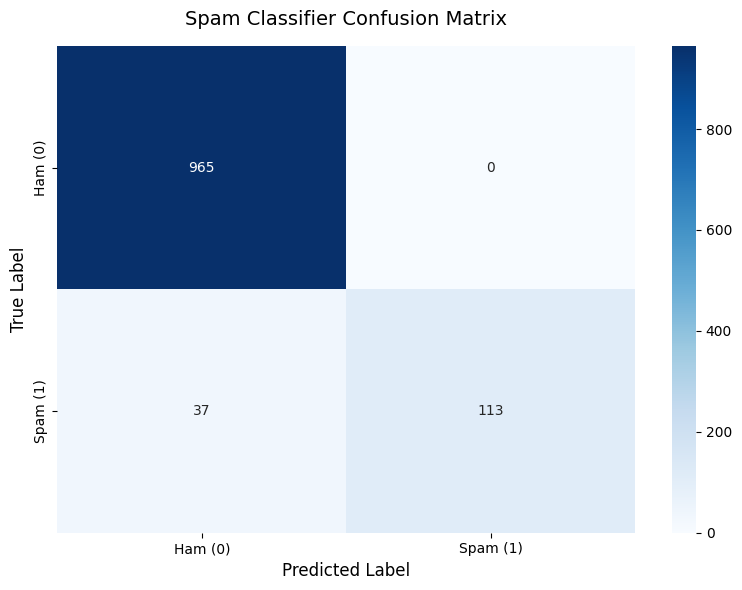

In [20]:
# Visualize the Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham (0)', 'Spam (1)'], yticklabels=['Ham (0)', 'Spam (1)' ])
plt.title('Spam Classifier Confusion Matrix', fontsize=14, pad=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()